# 32. MS 6x6 제약 위반량 분포

## 왜 이걸 보는가

notebook 30, 31에서 QA는 40회 실행 전부 feasible 0%였습니다. 기록된 것은 **best sample 하나의 위반량**뿐입니다.

| 실험 | 최소 위반량 |
|---|---|
| notebook 30 (alpha=1.5) | 24 ~ 87 |
| notebook 31 (alpha 0.5~3.0) | 26 ~ 120 |

그런데 "최소 위반 26"이라는 숫자 하나로는 두 상황을 구분할 수 없습니다.

| 상황 | 의미 |
|---|---|
| 낮은 위반이 **두텁게** 쌓여 있는데 0만 못 찍음 | 거의 다 왔다. 정밀도를 조금만 올려도 feasible이 나올 수 있다 |
| 26이 **외톨이**이고 대부분 훨씬 큼 | 구조적으로 멀다. 정밀도 개선으로 넘을 수 있는 거리가 아니다 |

등식 제약이라 위반 0만이 feasible이므로, **0 근처의 밀도**가 핵심입니다.

## 비교 대상

같은 QUBO를 SA로 풀면 97.7%가 feasible입니다. SA와 QA의 위반량 분포를 나란히 놓으면 하드웨어가 무엇을 잃는지 한눈에 보입니다.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from src.config import load_config, resolve_path

config = load_config(PROJECT_ROOT / "config" / "experiment_config.yaml")
DATA_DIR = resolve_path(config, "data_dir")
RAW_DIR = resolve_path(config, "raw_dir")
PROCESSED_DIR = resolve_path(config, "processed_dir")
FIGURE_DIR = resolve_path(config, "figure_dir")
EMBEDDING_DIR = RAW_DIR / "embeddings"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
print("설정 로드 완료")


설정 로드 완료


## 설정

`ALPHA_LIST`에 넣은 각 alpha로 QA를 다시 실행해 **전체 sample의 위반량**을 수집합니다. notebook 30/31은 best만 저장했으므로 재실행이 필요합니다.

`RUN_QA=False`로 두면 QA를 건너뛰고 SA 분포만 봅니다. QPU 없이 먼저 확인하실 때 쓰십시오.

In [ ]:
TARGET_INSTANCE = "6x6"
TARGET_FORMULATION = "MS"
TARGET_TOPOLOGY = "pegasus"

RUN_QA = True
SEEDS = [2024, 2026]            # embedding seed
ALPHA_LIST = [0.7, 1.5]         # 31에서 최선(0.7)과 본 실험값(1.5)
NUM_READS = 1000
ANNEALING_TIME = 150.0
EMBED_TRIES = 10
EMBED_TIMEOUT = 2400

print(f"QA 실행 : {RUN_QA}")
print(f"alpha   : {ALPHA_LIST}")
print(f"seed    : {SEEDS}")

QA 실행 : True
alpha   : [0.7, 1.5]
seed    : [2024]


## QUBO 준비

In [10]:
from src.data_generator import CFLPInstance
from src.qubo_builder import build_qubo
from src import fixed_embedding_qa as FQ

instance = CFLPInstance.load(DATA_DIR / f"{TARGET_INSTANCE}.json")
model = build_qubo(
    instance,
    TARGET_FORMULATION,
    float(config["penalty"]["margin"]),
    int(config["encoding"]["precision"]),
)
tolerance = float(config["feasibility"]["tolerance"])
print(f"변수 {model.num_variables}, 이차항 {model.num_quadratic_terms}")
print(f"총 수요 {instance.total_demand}  (위반량을 이 값과 비교하면 상대적 크기를 알 수 있습니다)")

변수 259, 이차항 8701
총 수요 226  (위반량을 이 값과 비교하면 상대적 크기를 알 수 있습니다)


## SA 기준선

본 실험과 동일한 SA 설정으로 위반량 분포를 구합니다. 이것이 **"QUBO 자체는 풀 수 있다"**는 기준선입니다.

In [11]:
import neal
from src.sa_solver import to_bqm

bqm = to_bqm(model)
sa_sampleset = neal.SimulatedAnnealingSampler().sample(
    bqm,
    num_reads=int(config["sa"]["num_reads"]),
    num_sweeps=int(config["sa"]["num_sweeps"]),
    seed=int(config["sa"]["seed"]),
)
sa_dist = FQ.violation_distribution(model, instance, sa_sampleset, tolerance)
sa_stat = FQ.violation_summary(model, instance, sa_sampleset, tolerance)
print("[SA] 위반량 분포")
display(sa_dist)
print("[SA] 요약", {k: round(v, 2) if isinstance(v, float) else v
                     for k, v in sa_stat.items()})

[SA] 위반량 분포


,range,count,fraction
0,0 (feasible),977,0.977
1,"(0, 1]",21,0.021
2,"(1, 2]",0,0.000
3,"(2, 3]",1,0.001
4,"(3, 5]",1,0.001
5,"(5, 10]",0,0.000
6,"(10, 20]",0,0.000
7,"(20, 50]",0,0.000
8,"(50, 100]",0,0.000
9,> 100,0,0.000


[SA] 요약 {'min_violation': 0.0, 'p01_violation': 0.0, 'p05_violation': 0.0, 'median_violation': 0.0, 'max_violation': 4.0, 'num_violation_le_1': 998, 'num_violation_le_3': 999, 'num_violation_le_5': 1000, 'num_violation_le_10': 1000}


## QA 실행 및 위반량 수집

embedding은 notebook 30에서 저장한 것을 재사용합니다. alpha만 바꿔가며 전체 sample의 위반량을 수집합니다.

In [ ]:
import time

distributions = {"SA": sa_dist.set_index("range")["count"]}
summaries = [dict(source="SA", **sa_stat)]

def log(message):
    """어디서 시간이 걸리는지 보이도록 진행 상황을 찍는다."""
    print(f"[{time.strftime('%H:%M:%S')}] {message}", flush=True)

if RUN_QA:
    log("dwave.system import 중")
    from dwave.system import DWaveSampler, FixedEmbeddingComposite
    from src import qa_solver
    log("import 완료")

    for seed in SEEDS:
        log(f"seed {seed}: embedding 확보 시작")
        embedding, meta = FQ.obtain_embedding(
            instance=instance,
            formulation=TARGET_FORMULATION,
            config=config,
            seed=seed,
            tries=EMBED_TRIES,
            timeout=EMBED_TIMEOUT,
            topology=TARGET_TOPOLOGY,
            embedding_dir=EMBEDDING_DIR,
        )
        log(
            f"seed {seed}: embedding 확보 완료 "
            f"(큐빗 {meta['physical_qubits']}, "
            f"재사용={meta.get('reused')})"
        )

        log(f"solver 접속: {meta['solver_id']}")
        sampler = DWaveSampler(solver=meta["solver_id"])
        composite = FixedEmbeddingComposite(sampler, embedding)
        log("composite 준비 완료")

        for alpha in ALPHA_LIST:
            chain_strength = qa_solver.compute_chain_strength(bqm, alpha)
            log(
                f"alpha={alpha}: QPU 제출 "
                f"(chain_strength={chain_strength:.3e}) — "
                f"큐 대기가 길 수 있습니다"
            )
            started = time.perf_counter()
            sampleset = composite.sample(
                bqm,
                num_reads=NUM_READS,
                annealing_time=ANNEALING_TIME,
                chain_strength=chain_strength,
                answer_mode="raw",
            )
            sampleset.resolve()
            log(f"alpha={alpha}: QPU 응답 수신 ({time.perf_counter()-started:.1f}s)")

            label = f"QA a={alpha} seed={seed}"
            started = time.perf_counter()
            violations, weights = FQ.sample_violations(
                model, instance, sampleset, tolerance
            )
            dist = FQ.violation_distribution(
                model, instance, sampleset, tolerance
            )
            stat = FQ.violation_summary(
                model, instance, sampleset, tolerance
            )
            log(f"alpha={alpha}: 위반량 분석 완료 ({time.perf_counter()-started:.1f}s)")

            distributions[label] = dist.set_index("range")["count"]
            summaries.append(dict(source=label, seed=seed, **stat))
            print(
                f"  -> 최소 위반 {stat['min_violation']:.0f}, "
                f"위반<=3 인 sample {stat['num_violation_le_3']}개, "
                f"feasible {int(dist.iloc[0]['count'])}개"
            )
    log("전체 완료")
else:
    print("RUN_QA=False 이므로 SA 분포만 봅니다.")

[16:26:52] dwave.system import 중
[16:26:52] import 완료
[16:26:52] seed 2024: embedding 확보 시작
    [      ] QUBO 그래프 생성 중
    [   0.0s] QUBO 그래프 완료 (변수 259, 엣지 8701)
    [      ] QPU 접속 중 (working graph 조회)
    [   0.1s] QPU 접속 완료: Advantage_system6;graph_id=01dae5a273 (엣지 40088)
    [   0.0s] 그래프 지문 계산 완료
    [      ] 저장본 발견: 6x6_MS_qpu-pegasus_seed2024_tries10.json, 유효성 검사 중
    [   0.1s] 유효성 검사 완료
저장된 embedding 재사용: 6x6_MS_qpu-pegasus_seed2024_tries10.json
[16:26:53] seed 2024: embedding 확보 완료 (큐빗 4503, 재사용=True)
[16:26:53] solver 접속: Advantage_system6;graph_id=01dae5a273
[16:26:53] composite 준비 완료
[16:26:53] alpha=0.7: QPU 제출 (chain_strength=1.002e+07) — 큐 대기가 길 수 있습니다
[16:26:55] alpha=0.7: QPU 응답 수신 (2.4s)
[16:26:55] alpha=0.7: 위반량 분석 완료 (0.1s)
  -> 최소 위반 14, 위반<=3 인 sample 0개, feasible 0개
[16:26:55] alpha=1.5: QPU 제출 (chain_strength=2.148e+07) — 큐 대기가 길 수 있습니다
[16:26:58] alpha=1.5: QPU 응답 수신 (2.4s)
[16:26:58] alpha=1.5: 위반량 분석 완료 (0.1s)
  -> 최소 위반 32, 위반<=3 인 sample 0개, feasible 0개


## 분포 비교

각 구간의 sample 수입니다. **0 근처 구간에 얼마나 쌓여 있는지**가 핵심입니다.

In [13]:
comparison = pd.DataFrame(distributions).fillna(0).astype(int)
comparison

,SA,QA a=0.7,QA a=1.5
range,,,
0 (feasible),977,0,0
"(0, 1]",21,0,0
"(1, 2]",0,0,0
"(2, 3]",1,0,0
"(3, 5]",1,0,0
"(5, 10]",0,0,0
"(10, 20]",0,3,0
"(20, 50]",0,292,6
"(50, 100]",0,664,223


In [14]:
summary_frame = pd.DataFrame(summaries)
summary_frame.round(2)

,source,min_violation,p01_violation,p05_violation,median_violation,max_violation,num_violation_le_1,num_violation_le_3,num_violation_le_5,num_violation_le_10,seed
0,SA,0.0,0.00,0.00,0.0,4.0,998,999,1000,1000,NaN
1,QA a=0.7,14.0,26.00,33.00,61.0,137.0,0,0,0,0,2024.0
2,QA a=1.5,32.0,56.98,74.95,128.0,285.0,0,0,0,0,2024.0


## Figure

가로축이 위반량 구간, 세로축이 sample 수(log)입니다. SA는 0에 몰려 있고 QA가 어디에 몰려 있는지 봅니다.

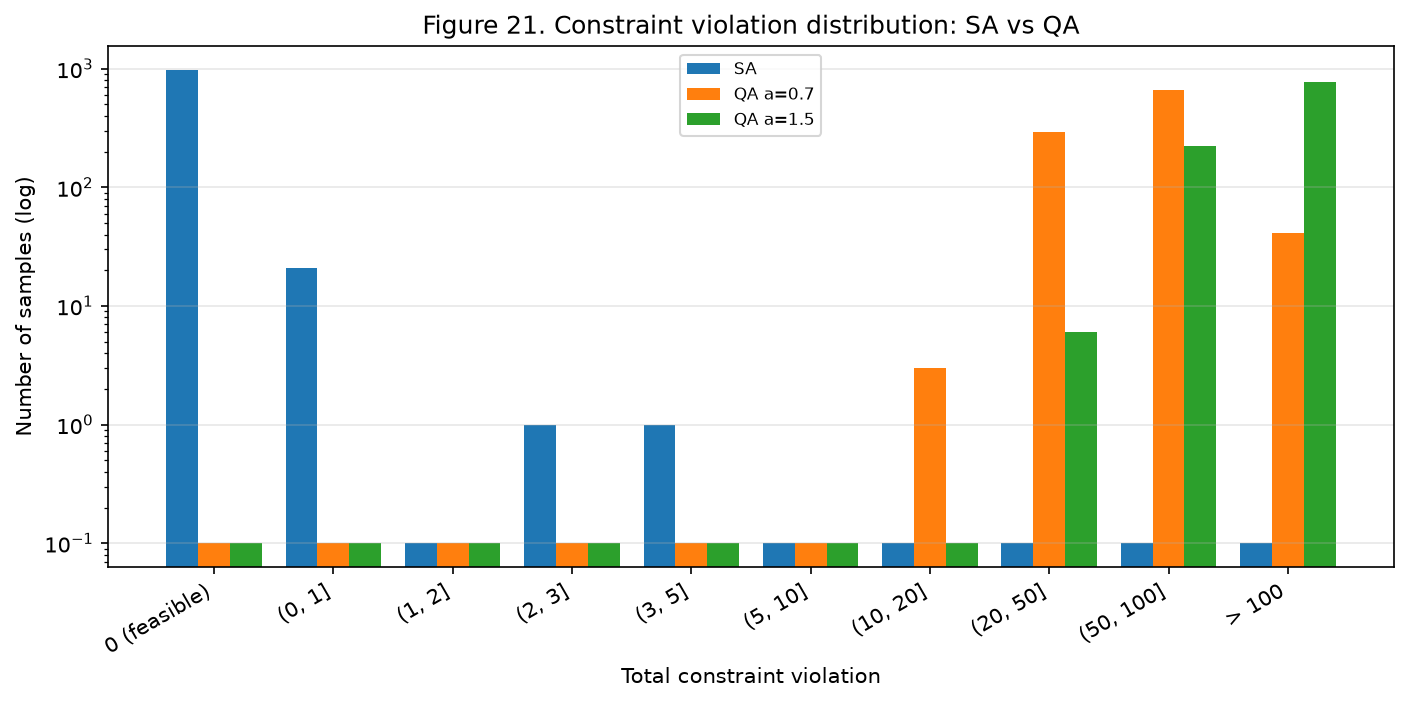

In [15]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(9.5, 4.8))
labels = list(comparison.index)
positions = np.arange(len(labels), dtype=float)
width = 0.8 / max(len(comparison.columns), 1)
for offset, column in enumerate(comparison.columns):
    axis.bar(
        positions - 0.4 + width * (offset + 0.5),
        comparison[column].clip(lower=0.1),
        width=width, label=column,
    )
axis.set_yscale("log")
axis.set_xticks(positions)
axis.set_xticklabels(labels, rotation=30, ha="right")
axis.set_xlabel("Total constraint violation")
axis.set_ylabel("Number of samples (log)")
axis.set_title("Figure 21. Constraint violation distribution: SA vs QA")
axis.grid(axis="y", alpha=0.3)
axis.legend(fontsize=8)
figure.tight_layout()
path = FIGURE_DIR / "figure21_violation_distribution.png"
figure.savefig(path, dpi=150, bbox_inches="tight")
plt.close(figure)
from IPython.display import Image
Image(filename=str(path))

## 저장

In [16]:
from src.persistence import save_table

save_table(
    comparison.reset_index(), PROCESSED_DIR,
    "ms6x6_violation_distribution.csv",
)
save_table(
    summary_frame, PROCESSED_DIR, "ms6x6_violation_summary.csv"
)
print("저장 완료")

저장 완료


## 해석 메모

직접 확인하십시오.

1. **QA의 위반량 최빈 구간이 어디인가**
   - 0~5 구간에 두텁게 쌓여 있다면 "거의 다 왔다"는 뜻입니다. 정밀도를 조금만 개선해도 feasible이 나올 수 있습니다.
   - 20~50 이상에 몰려 있다면 best sample의 낮은 위반이 외톨이였다는 뜻이고, 구조적으로 멉니다.
2. **`num_violation_le_3`가 몇 개인가**
   - 1,000개 중 한 자릿수면 우연에 가깝습니다.
   - 수십 개라면 분포가 0 쪽으로 밀려 있다는 뜻입니다.
3. **alpha 0.7과 1.5의 분포 차이**
   - notebook 31에서 최소 위반이 40% 줄었는데, 분포 전체가 이동한 것인지 꼬리만 좋아진 것인지 확인하십시오.
4. **SA와의 격차**
   - SA는 97.7%가 위반 0입니다. QA 분포가 그것과 얼마나 떨어져 있는지가 하드웨어가 잃는 양입니다.

**주의**: 이 notebook은 진단 실험입니다. 여기서 얻은 alpha나 설정을 본 실험 값으로 채택하지 마십시오.